# EasyOCR × UIT-HWDB — fine-tune recognizer chữ viết tay tiếng Việt

Notebook này trả lời đúng một câu hỏi thực nghiệm:

> **EasyOCR Latin Gen2 gốc có tốt hơn hay kém hơn chính model đó sau khi chúng ta fine-tune trên UIT-HWDB?**

So sánh chính là **EasyOCR pretrained → EasyOCR fine-tuned by us**.

Quy tắc nghiên cứu:

- cùng kiến trúc `None-VGG-BiLSTM-CTC`, cùng character set và cùng preprocessing;
- chỉ huấn luyện recognizer; detector không tham gia benchmark để tránh nhiễu do crop;
- split train/validation theo `writer_id`; official test chỉ dùng sau model selection;
- lưu baseline trước optimizer step, đánh giá epoch 0, rồi mới fine-tune;
- checkpoint fine-tuned tốt nhất và checkpoint được chọn để triển khai là hai khái niệm riêng;
- nếu fine-tune không thắng validation CER, bản triển khai giữ pretrained baseline.

**Phần cứng:** Kaggle T4. **Dataset:** `blue7012/UIT_HWDB`, CC BY 4.0 theo dataset card.


## 0. Thiết kế thí nghiệm

| Thành phần | Quy ước |
|---|---|
| Baseline | EasyOCR `latin_g2.pth` chính thức, version và SHA-256 được ghi lại |
| Fine-tuned | Cùng model, khởi tạo từ baseline; freeze CNN, fine-tune BiLSTM + CTC head |
| Train/validation | UIT-HWDB train, chia writer-disjoint bằng hash seed cố định |
| Test | UIT-HWDB official test line subset, không dùng chọn epoch/hyperparameter |
| Input | Ảnh dòng grayscale, cao 64 px, giữ tỉ lệ, right-pad tới 1024 px |
| Metric chính | Corpus CER; phụ: whitespace WER, Exact Match, latency |
| Model selection | Validation CER thấp nhất; baseline là ứng viên triển khai hợp lệ |
| Decoder | CTC greedy giống nhau cho cả hai model |

`CER/WER` càng thấp càng tốt. `Exact Match` càng cao càng tốt. Vì hai model dự đoán cùng các dòng test, notebook dùng paired bootstrap 95% CI cho delta.


In [24]:
CFG = {
    # Repo chứa source/project dùng trong notebook
    "repo_url": "https://github.com/taiiswibu/VietdocOCR_fine_tuning.git",
    # Nhánh/revision repo; notebook sẽ resolve và ghi lại commit SHA thực tế
    "repo_revision": "main",
    # Dataset UIT-HWDB public trên Hugging Face
    "dataset": "blue7012/UIT_HWDB",
    # Revision dataset; sẽ được khóa thành commit SHA để đảm bảo tái lập
    "dataset_revision": "main",
    # License khai báo của dataset
    "dataset_license": "cc-by-4.0",
    # Xác nhận đã đọc và chấp nhận license dataset
    "accept_dataset_license": True,
    # Seed cố định cho split và tính tái lập
    "seed": 42,
    # Tỷ lệ validation lấy từ train
    "val_fraction": 0.10,
    # Chỉ giữ label có độ dài tối đa 160 ký tự
    "max_label_length": 160,
    # Lọc ảnh có hình học giống dòng chữ
    "min_aspect_ratio": 1.2,
    # Phiên bản EasyOCR dùng trong thí nghiệm
    "easyocr_version": "1.7.2",
    # Ngôn ngữ recognizer
    "languages": ["vi", "en"],
    # Chiều cao ảnh đầu vào EasyOCR Latin Gen2
    "image_height": 64,
    # Chiều rộng ảnh đầu vào sau resize/padding
    "image_width": 1024,
    # Số ảnh xử lý trong một batch
    "batch_size": 16,
    # Gradient accumulation:
    # effective batch size = 16 × 2 = 32
    "grad_accum": 2,
    # Số epoch tối đa; có thể dừng sớm nhờ early stopping
    "epochs": 24,
    # Learning rate ban đầu cho AdamW
    "learning_rate": 3e-5,
    # Weight decay để regularization
    "weight_decay": 1e-4,
    # Nếu validation CER không cải thiện 3 epoch liên tiếp thì dừng
    "patience": 3,
    # Nếu CER tệ hơn baseline quá 0.15 trong nhiều epoch thì coi là regression nghiêm trọng
    "regression_margin_cer": 0.15,
    # Số worker đọc dữ liệu cho DataLoader
    "num_workers": 2,
    # Số lần bootstrap để tính khoảng tin cậy 95%
    "bootstrap_repeats": 2000,
    # Tên định danh cho experiment/run hiện tại
    "run_name": "easyocr_latin_g2_uithwdb_seed42_lr3e-5_v2",
}
# True: chạy fresh training.
# False: chỉ dùng khi RUN_DIR đã có checkpoint/history hoàn chỉnh.
RUN_TRAINING = True
# EasyOCR Latin Gen2 yêu cầu chiều cao ảnh là 64
assert CFG["image_height"] == 64, "EasyOCR Latin Gen2 dùng imgH=64."
# Đảm bảo image_width đủ lớn và chia hết cho 4
assert CFG["image_width"] >= 640 and CFG["image_width"] % 4 == 0

## 1. Môi trường Kaggle

Trước khi Run All:

1. Kaggle → **Settings → Accelerator → GPU T4**.
2. Bật Internet cho lần đầu tải repo, dataset và model EasyOCR.
3. Không cần `HF_TOKEN`: UIT-HWDB là public.
4. Chạy notebook từ trên xuống trong một session sạch.

Không cài VietOCR trong notebook này. Lỗi `No module named vietocr` của thí nghiệm trước không liên quan tới pipeline EasyOCR mới.


In [8]:
from pathlib import Path
import copy, hashlib, json, math, os, platform, random, shutil, subprocess, sys, time, unicodedata
from collections import Counter

KAGGLE = Path("/kaggle/input").exists()
WORK_PARENT = Path("/kaggle/working") if KAGGLE else Path.cwd()
ROOT = WORK_PARENT / "vietdoc-ocr"

def shell(*args, cwd=None):
    print("$", " ".join(map(str, args)))
    subprocess.run([str(x) for x in args], cwd=cwd, check=True)

if not ROOT.exists():
    shell("git", "clone", "--depth", "1", "--branch", CFG["repo_revision"], CFG["repo_url"], ROOT)
else:
    print("Reuse:", ROOT)

os.chdir(ROOT)
REPO_COMMIT = subprocess.check_output(["git", "rev-parse", "HEAD"], text=True).strip()
print("repo commit:", REPO_COMMIT)


Reuse: /kaggle/working/vietdoc-ocr
repo commit: 515d7ee81ec6c1bb90647b9414d307cf1b4e8886


In [9]:
# Cài đúng dependency của thí nghiệm. Không dùng extras OCR của project để tránh kéo VietOCR vào.
shell(
    sys.executable, "-m", "pip", "install", "-q",
    f"easyocr=={CFG['easyocr_version']}",
    "datasets==3.6.0", "huggingface-hub==0.31.4",
    "PyYAML>=6", "pandas>=2", "seaborn>=0.13", "tqdm>=4.66"
)


$ /usr/bin/python3 -m pip install -q easyocr==1.7.2 datasets==3.6.0 huggingface-hub==0.31.4 PyYAML>=6 pandas>=2 seaborn>=0.13 tqdm>=4.66


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageEnhance, ImageOps
from IPython.display import FileLink, display
from tqdm.auto import tqdm
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import easyocr

assert torch.cuda.is_available(), "Hãy bật GPU T4 rồi restart session."
assert easyocr.__version__ == CFG["easyocr_version"]
DEVICE = torch.device("cuda:0")

def seed_everything(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(CFG["seed"])
print({"python": platform.python_version(), "torch": torch.__version__,
       "easyocr": easyocr.__version__, "gpu": torch.cuda.get_device_name(0)})


{'python': '3.12.13', 'torch': '2.10.0+cu128', 'easyocr': '1.7.2', 'gpu': 'Tesla T4'}


## 2. Chuẩn bị UIT-HWDB và khóa split

Cell này tự chuẩn bị dữ liệu, không phụ thuộc script fine-tune VietOCR cũ trong repository. Nó stream dataset public, NFC-normalize transcript, giữ ảnh dạng dòng, bỏ duplicate theo SHA-256, giữ official test riêng và chia train/validation theo `writer_id`. Thư mục mới được dùng để không ghi đè một lần chuẩn bị cũ.


In [11]:
DATA_DIR = ROOT / "data" / f"uit-hwdb-line-easyocr-seed{CFG['seed']}-val{int(CFG['val_fraction']*100)}"
RUN_DIR = ROOT / "runs" / CFG["run_name"]
PLOT_DIR = RUN_DIR / "plots"
PACKAGE_DIR = RUN_DIR / "packages"
for path in (RUN_DIR, PLOT_DIR, PACKAGE_DIR): path.mkdir(parents=True, exist_ok=True)

manifests = [DATA_DIR / f"{s}.jsonl" for s in ("train", "val", "test")]
if not all(p.exists() for p in manifests):
    assert CFG["accept_dataset_license"], "Đọc dataset card/license rồi đặt accept_dataset_license=True."
    assert not DATA_DIR.exists() or not any(DATA_DIR.iterdir()), f"Dọn thư mục prepare dở dang: {DATA_DIR}"
    from datasets import load_dataset
    from huggingface_hub import HfApi

    resolved_revision = HfApi().dataset_info(CFG["dataset"], revision=CFG["dataset_revision"]).sha
    DATA_DIR.mkdir(parents=True, exist_ok=True); (DATA_DIR / "images").mkdir(exist_ok=True)
    handles = {s: (DATA_DIR / f"{s}.jsonl").open("w", encoding="utf-8") for s in ("train", "val", "test")}
    counts, rejected, seen = Counter(), [], set()
    detected_columns = None

    def normalized(value):
        text = unicodedata.normalize("NFC", str(value))
        text = "".join(c for c in text if not unicodedata.category(c).startswith("C"))
        return " ".join(text.split())

    def writer_split(writer_id):
        digest = hashlib.sha256(f"{CFG['seed']}:{writer_id}".encode()).hexdigest()
        return "val" if int(digest[:8], 16) / 2**32 < CFG["val_fraction"] else "train"

    try:
        for source_split in ("test", "train"):
            stream = load_dataset(CFG["dataset"], split=source_split,
                                  revision=resolved_revision, streaming=True)
            for index, row in enumerate(stream):
                if detected_columns is None:
                    image_col = next((k for k, v in row.items() if isinstance(v, Image.Image)), None)
                    text_col = next((k for k in ("text", "label", "transcription", "sentence", "ground_truth")
                                     if isinstance(row.get(k), str)), None)
                    group_col = "writer_id" if "writer_id" in row else None
                    if not image_col or not text_col or not group_col:
                        raise ValueError(f"Cần image/text/writer_id; schema hiện tại: {list(row)}")
                    detected_columns = {"image": image_col, "text": text_col, "group": group_col}
                try:
                    image = ImageOps.exif_transpose(row[detected_columns["image"]]).convert("RGB")
                    text = normalized(row[detected_columns["text"]])
                    writer_id = normalized(row[detected_columns["group"]])
                    if not text or not writer_id or image.width < 3 or image.height < 3:
                        raise ValueError("empty_text_writer_or_tiny_image")
                    if len(text) > CFG["max_label_length"]:
                        raise ValueError(f"label_too_long:{len(text)}")
                    aspect = image.width / image.height
                    if aspect < CFG["min_aspect_ratio"]:
                        raise ValueError(f"non_line_aspect:{aspect:.3f}")
                    image_sha = hashlib.sha256(str(image.size).encode() + image.tobytes()).hexdigest()
                    if image_sha in seen:
                        counts["duplicates_removed"] += 1; continue
                    seen.add(image_sha)
                    destination = "test" if source_split == "test" else writer_split(writer_id)
                    relative = f"images/{source_split}-{index:07d}.png"
                    image.save(DATA_DIR / relative)
                    record = {"id": f"{source_split}-{index}", "image": relative, "text": text,
                              "sha256": image_sha, "writer_id": writer_id,
                              "source_split": source_split, "width": image.width,
                              "height": image.height, "aspect_ratio": aspect}
                    handles[destination].write(json.dumps(record, ensure_ascii=False) + "\n")
                    counts[destination] += 1
                    if index % 2000 == 0: print(source_split, index, dict(counts), flush=True)
                except Exception as exc:
                    rejected.append({"split": source_split, "index": index, "reason": str(exc)})
    finally:
        for handle in handles.values(): handle.close()

    preparation = {
        "dataset": CFG["dataset"], "revision": resolved_revision,
        "declared_license": CFG["dataset_license"], "seed": CFG["seed"],
        "val_fraction": CFG["val_fraction"], "columns": detected_columns,
        "counts": dict(counts), "rejected": rejected,
        "line_filter": {"max_label_length": CFG["max_label_length"],
                        "min_aspect_ratio": CFG["min_aspect_ratio"]},
        "split_policy": "Official test reserved; duplicate images removed; train/val writer-disjoint by writer_id hash."
    }
    (DATA_DIR / "preparation.json").write_text(
        json.dumps(preparation, ensure_ascii=False, indent=2), encoding="utf-8")
    assert all(counts[s] for s in ("train", "val", "test")), preparation["counts"]

def read_jsonl(path):
    return [json.loads(x) for x in Path(path).read_text(encoding="utf-8").splitlines() if x.strip()]

rows = {s: read_jsonl(DATA_DIR / f"{s}.jsonl") for s in ("train", "val", "test")}
prep = json.loads((DATA_DIR / "preparation.json").read_text(encoding="utf-8"))
print({s: len(v) for s, v in rows.items()})
print("dataset revision:", prep["revision"])


{'train': 6241, 'val': 836, 'test': 201}
dataset revision: 3f6ff77c867cd29a614db205e4a176a1aa052b31


In [12]:
# Leakage audit: image và writer không được giao nhau giữa các split.
for a, b in (("train", "val"), ("train", "test"), ("val", "test")):
    sha_overlap = {r["sha256"] for r in rows[a]} & {r["sha256"] for r in rows[b]}
    writer_overlap = {r["writer_id"] for r in rows[a]} & {r["writer_id"] for r in rows[b]}
    assert not sha_overlap, (a, b, "image leakage", len(sha_overlap))
    assert not writer_overlap, (a, b, "writer leakage", len(writer_overlap))
assert all(rows[s] for s in rows)
print("✅ No image/writer leakage")


✅ No image/writer leakage


## 3. Khởi tạo EasyOCR baseline chính thức

`detector=False` là có chủ đích: dataset đã là ảnh dòng. Ta chỉ đo recognizer để biết thay đổi có thật sự đến từ fine-tuning hay không. Character order của `latin_g2` được giữ nguyên; notebook **không thay output layer**.


In [25]:
MODEL_STORAGE = ROOT / "models" / "easyocr"
MODEL_STORAGE.mkdir(parents=True, exist_ok=True)
reader = easyocr.Reader(
    CFG["languages"], gpu="cuda", detector=False, recognizer=True,
    model_storage_directory=str(MODEL_STORAGE), quantize=False, verbose=True
)
assert reader.model_lang == "latin"
model = reader.recognizer
converter = reader.converter
character = reader.character
assert len(converter.character) == len(character) + 1  # blank CTC ở index 0

BASE_MODEL_PATH = MODEL_STORAGE / "latin_g2.pth"
def sha256_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""): h.update(chunk)
    return h.hexdigest()

baseline_sha256 = sha256_file(BASE_MODEL_PATH)
character_sha256 = hashlib.sha256(character.encode("utf-8")).hexdigest()
print({"model": str(BASE_MODEL_PATH), "sha256": baseline_sha256,
       "characters": len(character), "character_sha256": character_sha256})


{'model': '/kaggle/working/vietdoc-ocr/models/easyocr/latin_g2.pth', 'sha256': 'aaa95be1c4a9cb3496879bed7c520886ce1164f89e026f0c54488394e74e8c55', 'characters': 351, 'character_sha256': 'f6f61866a083d7b06e4fa0af37cccbd2229ceaf382ee5c438a322dbb7381d4db'}


In [26]:
# Audit character coverage trên train/validation TRƯỚC train.
# Không đọc test label để đưa ra quyết định và không âm thầm thay CTC head.
unknown = Counter()
for split in ("train", "val"):
    for row in rows[split]:
        unknown.update(c for c in row["text"] if c not in converter.dict)
if unknown:
    print("Unsupported characters:", unknown.most_common())
    raise ValueError("Dataset có ký tự ngoài EasyOCR latin_g2. Cần quyết định vocab có kiểm soát, không train tiếp.")
print("✅ 100% transcript characters are covered by the original EasyOCR head")


✅ 100% transcript characters are covered by the original EasyOCR head


## 4. EDA trước huấn luyện

Chỉ xem train/validation ở đây. Test chưa được dùng để chọn quyết định.


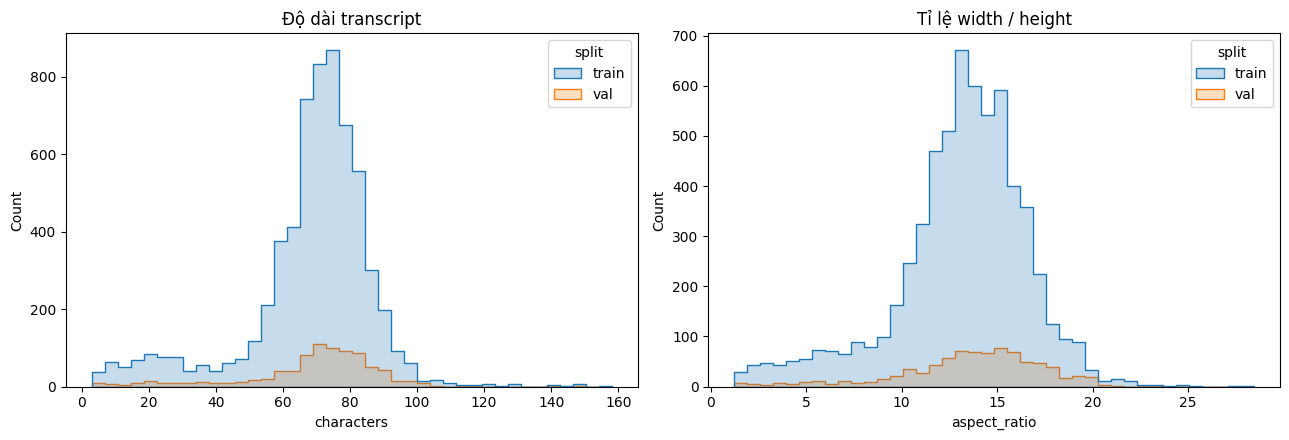

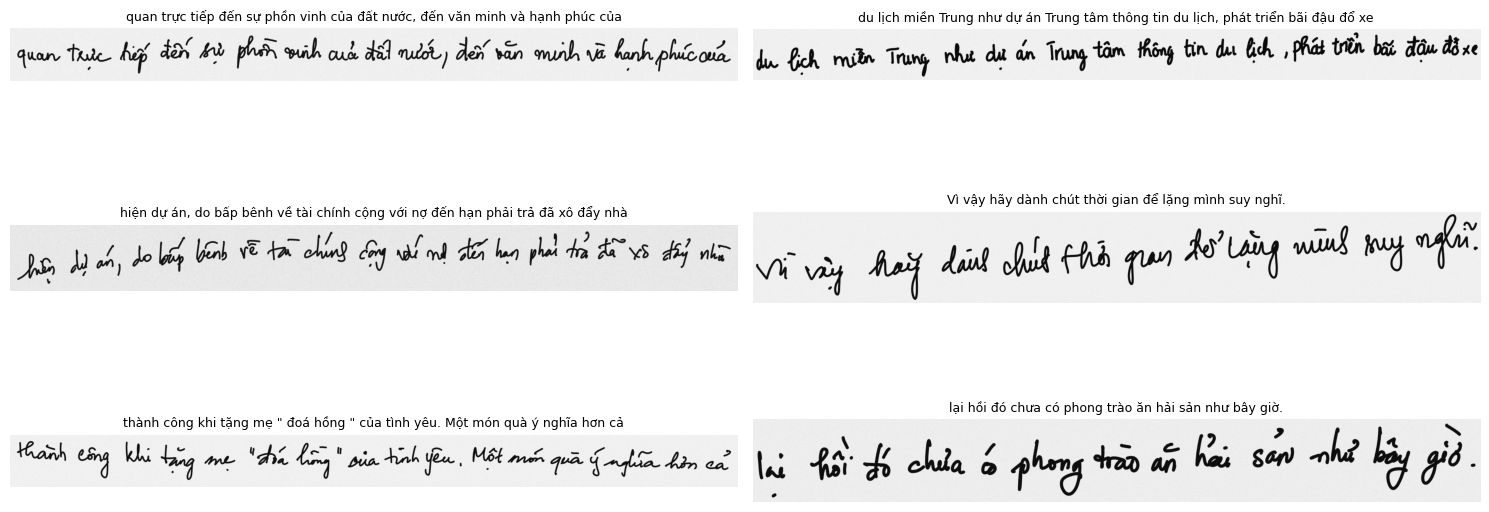

In [27]:
eda = pd.DataFrame([
    {"split": split, "characters": len(r["text"]), "aspect_ratio": r["aspect_ratio"]}
    for split in ("train", "val") for r in rows[split]
])
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(eda, x="characters", hue="split", bins=40, element="step", ax=axes[0])
sns.histplot(eda, x="aspect_ratio", hue="split", bins=40, element="step", ax=axes[1])
axes[0].set_title("Độ dài transcript"); axes[1].set_title("Tỉ lệ width / height")
fig.tight_layout(); fig.savefig(PLOT_DIR / "eda.png", dpi=160, bbox_inches="tight"); plt.show()

rng = np.random.default_rng(CFG["seed"])
sample = rng.choice(rows["train"], size=min(6, len(rows["train"])), replace=False)
fig, axes = plt.subplots(3, 2, figsize=(15, 7))
for ax, row in zip(axes.flat, sample):
    ax.imshow(Image.open(DATA_DIR / row["image"]).convert("L"), cmap="gray")
    ax.set_title(row["text"][:90], fontsize=9); ax.axis("off")
fig.tight_layout(); plt.show()


## 5. Dataset và preprocessing giống EasyOCR

Ảnh được grayscale, resize về cao 64 px, giữ tỉ lệ và lặp cột biên phải để pad. Canvas cố định 1024 px giúp cả baseline và fine-tuned nhận đúng cùng tensor, đồng thời đủ CTC time steps cho nhãn dài. Augmentation nhẹ chỉ áp dụng cho train.


In [28]:
def clean_text(value):
    text = unicodedata.normalize("NFC", str(value))
    text = "".join(c for c in text if not unicodedata.category(c).startswith("C"))
    return " ".join(text.split())

class LineDataset(Dataset):
    def __init__(self, records, root, augment=False):
        self.records, self.root, self.augment = records, Path(root), augment
    def __len__(self): return len(self.records)
    def __getitem__(self, index):
        row = self.records[index]
        image = Image.open(self.root / row["image"])
        image = ImageOps.exif_transpose(image).convert("L")
        if self.augment:
            image = ImageEnhance.Contrast(image).enhance(random.uniform(0.85, 1.15))
            image = ImageEnhance.Brightness(image).enhance(random.uniform(0.90, 1.10))
        return image, clean_text(row["text"]), row["id"]

class EasyOCRLineCollate:
    def __init__(self, height, width): self.height, self.width = height, width
    def __call__(self, batch):
        tensors, texts, ids = [], [], []
        for image, text, sample_id in batch:
            ratio = image.width / max(image.height, 1)
            resized_w = min(self.width, max(1, math.ceil(self.height * ratio)))
            image = image.resize((resized_w, self.height), Image.Resampling.BICUBIC)
            arr = np.asarray(image, dtype=np.float32) / 255.0
            tensor = torch.from_numpy(arr).unsqueeze(0).sub(0.5).div(0.5)
            canvas = torch.empty((1, self.height, self.width), dtype=torch.float32)
            canvas[:, :, :resized_w] = tensor
            if resized_w < self.width:
                canvas[:, :, resized_w:] = tensor[:, :, -1:].expand(1, self.height, self.width - resized_w)
            tensors.append(canvas); texts.append(text); ids.append(sample_id)
        return torch.stack(tensors), texts, ids

collate = EasyOCRLineCollate(CFG["image_height"], CFG["image_width"])
train_loader = DataLoader(LineDataset(rows["train"], DATA_DIR, augment=True),
    batch_size=CFG["batch_size"], shuffle=True, num_workers=CFG["num_workers"],
    pin_memory=True, persistent_workers=CFG["num_workers"] > 0, collate_fn=collate)
val_loader = DataLoader(LineDataset(rows["val"], DATA_DIR),
    batch_size=CFG["batch_size"], shuffle=False, num_workers=CFG["num_workers"],
    pin_memory=True, persistent_workers=CFG["num_workers"] > 0, collate_fn=collate)
test_loader = DataLoader(LineDataset(rows["test"], DATA_DIR),
    batch_size=CFG["batch_size"], shuffle=False, num_workers=CFG["num_workers"],
    pin_memory=True, persistent_workers=CFG["num_workers"] > 0, collate_fn=collate)


In [29]:
def unwrap(m): return m.module if hasattr(m, "module") else m
def required_ctc_steps(text):
    return len(text) + sum(a == b for a, b in zip(text, text[1:]))

# Preflight thật bằng model: kiểm tra output shape và CTC feasibility.
model.eval()
with torch.no_grad():
    dummy = torch.zeros(1, 1, CFG["image_height"], CFG["image_width"], device=DEVICE)
    time_steps = model(dummy, torch.zeros(1, 1, dtype=torch.long, device=DEVICE)).shape[1]
infeasible = [(s, r["id"], required_ctc_steps(r["text"])) for s in rows for r in rows[s]
              if required_ctc_steps(r["text"]) > time_steps]
assert not infeasible, f"CTC-infeasible labels: {infeasible[:10]}"
print({"ctc_time_steps": time_steps, "max_required": max(required_ctc_steps(r["text"]) for s in rows for r in rows[s])})


{'ctc_time_steps': 255, 'max_required': 159}


## 6. Metric và baseline epoch 0

Baseline state được copy vào CPU trước bất kỳ optimizer step nào. Đánh giá validation ở epoch 0 là điểm đối chứng thật, không phải số lấy từ README hay từ model của người khác.


In [30]:
def edit_distance(a, b):
    prev = list(range(len(b) + 1))
    for i, ca in enumerate(a, 1):
        cur = [i]
        for j, cb in enumerate(b, 1):
            cur.append(min(cur[-1] + 1, prev[j] + 1, prev[j-1] + (ca != cb)))
        prev = cur
    return prev[-1]

def aggregate_metrics(truths, predictions):
    char_edits = sum(edit_distance(t, p) for t, p in zip(truths, predictions))
    char_total = sum(len(t) for t in truths)
    word_edits = sum(edit_distance(t.split(), p.split()) for t, p in zip(truths, predictions))
    word_total = sum(len(t.split()) for t in truths)
    return {"cer": char_edits / max(char_total, 1),
            "wer": word_edits / max(word_total, 1),
            "exact_match": float(np.mean([t == p for t, p in zip(truths, predictions)])),
            "samples": len(truths)}

ignore_idx = [i + 1 for i, char in enumerate(character) if char not in set(reader.lang_char)]

@torch.no_grad()
def evaluate(current_model, loader):
    current_model.eval(); records = []; started = time.perf_counter()
    for images, texts, ids in tqdm(loader, leave=False):
        images = images.to(DEVICE, non_blocking=True)
        logits = current_model(images, torch.zeros(images.size(0), 1, dtype=torch.long, device=DEVICE))
        if ignore_idx: logits[:, :, ignore_idx] = -torch.inf
        indices = logits.argmax(2).cpu().numpy()
        lengths = np.full(images.size(0), logits.size(1), dtype=np.int32)
        predictions = converter.decode_greedy(indices.reshape(-1), lengths)
        records.extend({"id": i, "truth": t, "prediction": clean_text(p)}
                       for i, t, p in zip(ids, texts, predictions))
    elapsed = time.perf_counter() - started
    metrics = aggregate_metrics([r["truth"] for r in records], [r["prediction"] for r in records])
    metrics["seconds"] = elapsed; metrics["ms_per_line"] = elapsed * 1000 / max(len(records), 1)
    return metrics, records

baseline_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
baseline_val, baseline_val_pred = evaluate(model, val_loader)
print("Epoch 0 / EasyOCR pretrained validation:", baseline_val)


  0%|          | 0/53 [00:00<?, ?it/s]

Epoch 0 / EasyOCR pretrained validation: {'cer': 0.6140390416421068, 'wer': 0.9926095632251866, 'exact_match': 0.0, 'samples': 836, 'seconds': 6.818143208000038, 'ms_per_line': 8.15567369377995}


## 7. Fine-tune EasyOCR recognizer

CNN được freeze để giảm quên kiến thức pretrained và vừa VRAM 4–16 GB; BiLSTM + Prediction head được cập nhật bằng CTC loss. Đây vẫn là fine-tuning thật của EasyOCR, không phải huấn luyện model mới từ đầu.

Early stopping dựa trên validation CER. Regression guard dừng sớm nếu model lệch quá xa baseline trong hai epoch liên tiếp.


In [31]:
def save_easyocr_state(current_model, path):
    state = {k: v.detach().cpu() for k, v in current_model.state_dict().items()}
    # EasyOCR CUDA loader mong key có prefix module.; DataParallel thường đã có prefix này.
    if state and not next(iter(state)).startswith("module."):
        state = {"module." + k: v for k, v in state.items()}
    torch.save(state, path)

BEST_FT = RUN_DIR / "best-finetuned.pth"
HISTORY_PATH = RUN_DIR / "history.json"
history = [{"epoch": 0, "train_loss": None, **baseline_val}]

if RUN_TRAINING:
    model.load_state_dict(baseline_state)
    core = unwrap(model)
    for p in core.FeatureExtraction.parameters(): p.requires_grad = False
    trainable = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(trainable, lr=CFG["learning_rate"], weight_decay=CFG["weight_decay"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG["epochs"], eta_min=CFG["learning_rate"] / 10)
    criterion = nn.CTCLoss(blank=0, zero_infinity=True)
    scaler = torch.cuda.amp.GradScaler(enabled=True)
    best_ft_cer, best_ft_epoch, stale, severe_regression = float("inf"), None, 0, 0

    for epoch in range(1, CFG["epochs"] + 1):
        model.train(); core.FeatureExtraction.eval(); optimizer.zero_grad(set_to_none=True)
        total_loss = 0.0
        for step, (images, texts, _) in enumerate(tqdm(train_loader, desc=f"epoch {epoch}")):
            images = images.to(DEVICE, non_blocking=True)
            targets, target_lengths = converter.encode(texts)
            targets = targets.to(DEVICE)
            with torch.cuda.amp.autocast(enabled=True):
                logits = model(images, torch.zeros(images.size(0), 1, dtype=torch.long, device=DEVICE))
                log_probs = logits.log_softmax(2).permute(1, 0, 2)
                input_lengths = torch.full((images.size(0),), logits.size(1), dtype=torch.long)
                loss = criterion(log_probs, targets, input_lengths, target_lengths) / CFG["grad_accum"]
            scaler.scale(loss).backward()
            if (step + 1) % CFG["grad_accum"] == 0 or step + 1 == len(train_loader):
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(trainable, 5.0)
                scaler.step(optimizer); scaler.update(); optimizer.zero_grad(set_to_none=True)
            total_loss += loss.item() * CFG["grad_accum"]

        val_metrics, _ = evaluate(model, val_loader)
        row = {"epoch": epoch, "train_loss": total_loss / len(train_loader),
               "learning_rate": optimizer.param_groups[0]["lr"], **val_metrics}
        history.append(row); print(row); scheduler.step()

        if val_metrics["cer"] < best_ft_cer:
            best_ft_cer, best_ft_epoch, stale = val_metrics["cer"], epoch, 0
            save_easyocr_state(model, BEST_FT)
        else:
            stale += 1
        severe_regression = severe_regression + 1 if val_metrics["cer"] > baseline_val["cer"] + CFG["regression_margin_cer"] else 0
        HISTORY_PATH.write_text(json.dumps(history, ensure_ascii=False, indent=2), encoding="utf-8")
        if stale >= CFG["patience"] or severe_regression >= 2:
            print("Early stop:", {"stale_epochs": stale, "severe_regression_epochs": severe_regression}); break
else:
    assert BEST_FT.exists() and HISTORY_PATH.exists(), "RUN_TRAINING=False nhưng run chưa hoàn chỉnh."
    history = json.loads(HISTORY_PATH.read_text(encoding="utf-8"))
    best_ft_epoch = min(history[1:], key=lambda x: x["cer"])["epoch"]
    best_ft_cer = min(x["cer"] for x in history[1:])

print({"best_finetuned_epoch": best_ft_epoch, "best_finetuned_val_cer": best_ft_cer,
       "baseline_val_cer": baseline_val["cer"]})


/tmp/ipykernel_58/4267813394.py:20: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=True)


epoch 1:   0%|          | 0/391 [00:00<?, ?it/s]

/tmp/ipykernel_58/4267813394.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=True):


  0%|          | 0/53 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 2.6340204550482125, 'learning_rate': 3e-05, 'cer': 0.41125481085954024, 'wer': 0.9005247210110118, 'exact_match': 0.0, 'samples': 836, 'seconds': 6.22090837199994, 'ms_per_line': 7.441277956937727}


...

  0%|          | 0/53 [00:00<?, ?it/s]

{'epoch': 23, 'train_loss': 0.739859519254826, 'learning_rate': 3.4600013450975795e-06, 'cer': 0.2130473978017406, 'wer': 0.5881309585396497, 'exact_match': 0.007177033492822967, 'samples': 836, 'seconds': 6.223802408000665, 'ms_per_line': 7.444739722488834}


epoch 24:   0%|          | 0/391 [00:00<?, ?it/s]

  0%|          | 0/53 [00:00<?, ?it/s]

{'epoch': 24, 'train_loss': 0.7373631390769159, 'learning_rate': 3.11549437145356e-06, 'cer': 0.21247529558614472, 'wer': 0.5868006799201833, 'exact_match': 0.007177033492822967, 'samples': 836, 'seconds': 6.223450325999693, 'ms_per_line': 7.444318571769967}
{'best_finetuned_epoch': 24, 'best_finetuned_val_cer': 0.21247529558614472, 'baseline_val_cer': 0.6140390416421068}


## 8. Training curves và chọn checkpoint

Epoch 0 là EasyOCR gốc. Các epoch 1…N là model của chúng ta. “Best fine-tuned” luôn là epoch sau cập nhật tốt nhất; “deployment-selected” có thể vẫn là baseline nếu fine-tuning không cải thiện validation CER.


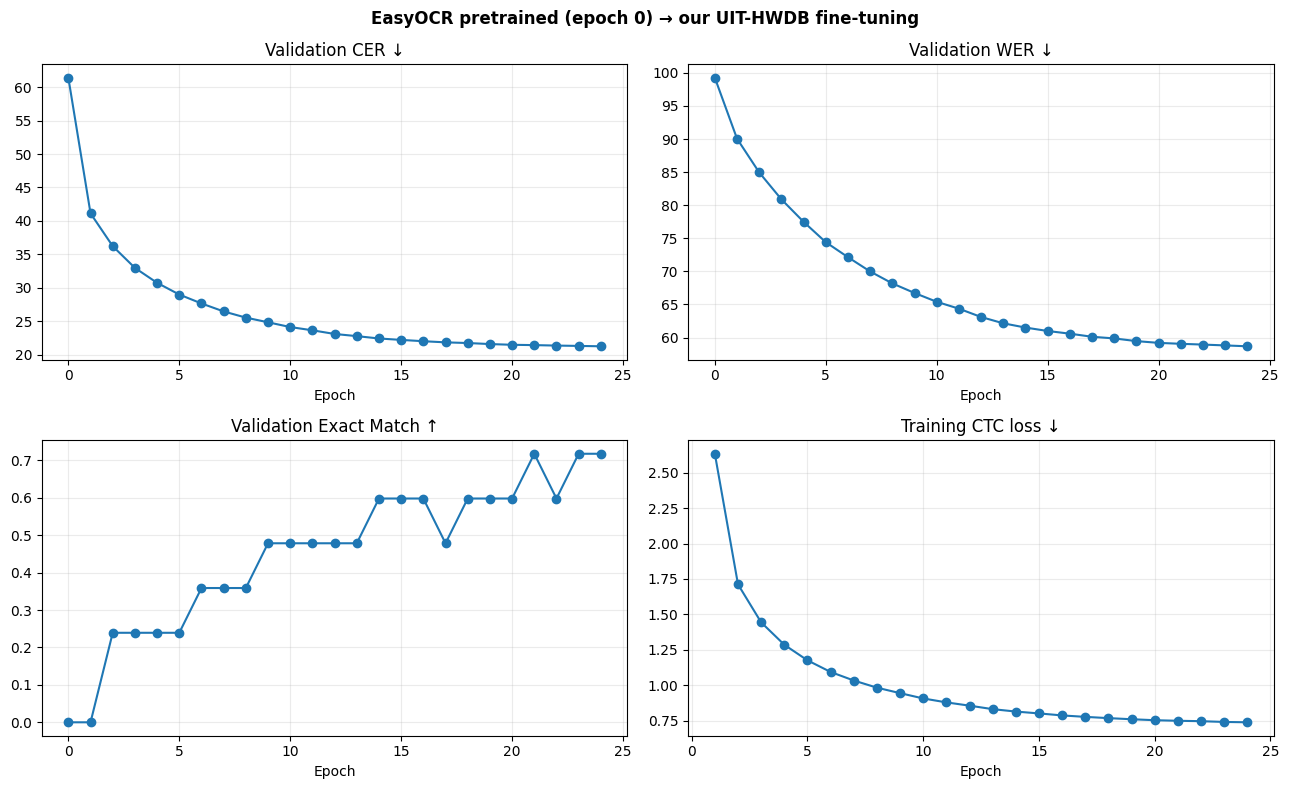

DEPLOYMENT SELECTED: fine-tuned epoch 24


In [32]:
history_df = pd.DataFrame(history)
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes[0,0].plot(history_df["epoch"], history_df["cer"] * 100, marker="o"); axes[0,0].set_title("Validation CER ↓")
axes[0,1].plot(history_df["epoch"], history_df["wer"] * 100, marker="o"); axes[0,1].set_title("Validation WER ↓")
axes[1,0].plot(history_df["epoch"], history_df["exact_match"] * 100, marker="o"); axes[1,0].set_title("Validation Exact Match ↑")
train_rows = history_df[history_df["epoch"] > 0]
axes[1,1].plot(train_rows["epoch"], train_rows["train_loss"], marker="o"); axes[1,1].set_title("Training CTC loss ↓")
for ax in axes.flat: ax.grid(alpha=.25); ax.set_xlabel("Epoch")
fig.suptitle("EasyOCR pretrained (epoch 0) → our UIT-HWDB fine-tuning", fontweight="bold")
fig.tight_layout(); fig.savefig(PLOT_DIR / "training-curves.png", dpi=170, bbox_inches="tight"); plt.show()

selected_source = "fine-tuned" if best_ft_cer < baseline_val["cer"] else "pretrained"
selected_epoch = best_ft_epoch if selected_source == "fine-tuned" else 0
print("DEPLOYMENT SELECTED:", selected_source, "epoch", selected_epoch)


## 9. Final test — cùng protocol, cùng sample

Chỉ đến đây official test mới được dùng. Baseline và best fine-tuned đều được load lại từ checkpoint độc lập rồi dự đoán đúng cùng thứ tự dòng.


In [36]:
def paired_bootstrap(base_records, fine_records, repeats, seed):
    # Khởi tạo bộ sinh số ngẫu nhiên với seed cố định để kết quả có thể tái lập
    rng = np.random.default_rng(seed)
    # Số lượng mẫu trong tập test
    n = len(base_records)
    # Lưu chênh lệch metric giữa fine-tuned và pretrained
    # Giá trị = fine-tuned - pretrained
    deltas = {
        "cer": [],
        "wer": [],
        "exact_match": []
    }
    # Lặp bootstrap nhiều lần
    for _ in range(repeats):
        # Lấy mẫu lại có hoàn lại (sampling with replacement)
        # Mỗi bootstrap sample vẫn có n phần tử
        idx = rng.integers(0, n, n)
        # Ground-truth tương ứng với các sample được lấy lại
        truths = [
            base_records[i]["truth"]
            for i in idx
        ]

        # Tính metric cho EasyOCR pretrained
        bm = aggregate_metrics(
            truths,
            [
                base_records[i]["prediction"]
                for i in idx
            ]
        )

        # Tính metric cho EasyOCR fine-tuned
        fm = aggregate_metrics(
            truths,
            [
                fine_records[i]["prediction"]
                for i in idx
            ]
        )

        # Lưu delta = fine-tuned - pretrained
        #
        # CER/WER:
        #   delta < 0  -> fine-tuned tốt hơn
        #   delta > 0  -> fine-tuned kém hơn
        #
        # Exact Match:
        #   delta > 0  -> fine-tuned tốt hơn
        #   delta < 0  -> fine-tuned kém hơn
        for key in deltas:
            deltas[key].append(
                fm[key] - bm[key]
            )
    # Tính:
    # - delta trung bình
    # - khoảng tin cậy bootstrap 95%
    return {
        k: {
            "delta_fine_minus_base": float(
                np.mean(v)
            ),

            # Percentile bootstrap:
            # 2.5% và 97.5%
            "ci95": [
                float(np.quantile(v, 0.025)),
                float(np.quantile(v, 0.975))
            ]
        }
        for k, v in deltas.items()
    }

# Chạy paired bootstrap trên cùng tập test
bootstrap = paired_bootstrap(
    base_pred,
    fine_pred,
    CFG["bootstrap_repeats"],
    CFG["seed"]
)
print(
    json.dumps(
        bootstrap,
        indent=2
    )
)

{
  "cer": {
    "delta_fine_minus_base": -0.3501726420800179,
    "ci95": [
      -0.3616244974713733,
      -0.3387867588110343
    ]
  },
  "wer": {
    "delta_fine_minus_base": -0.21152495666691373,
    "ci95": [
      -0.23327973711456998,
      -0.19001958557391796
    ]
  },
  "exact_match": {
    "delta_fine_minus_base": 0.004980099502487562,
    "ci95": [
      0.0,
      0.014925373134328358
    ]
  }
}


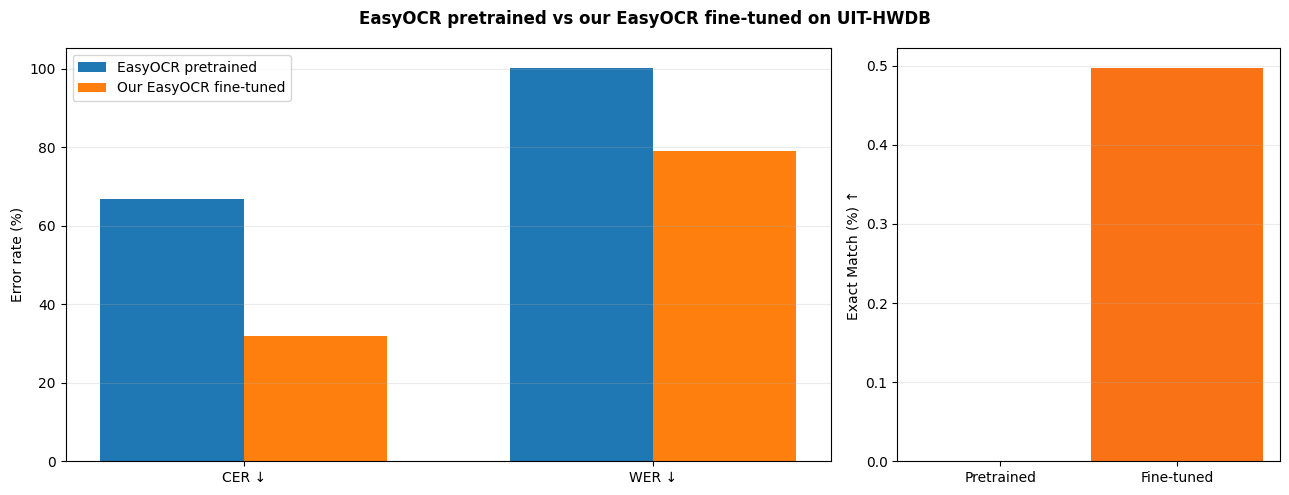

In [37]:
# CER/WER (thấp tốt) và Exact Match (cao tốt) phải ở hai trục riêng để không gây hiểu nhầm.
fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [2, 1]})
x = np.arange(2); width = .35
axes[0].bar(x-width/2, [base_test["cer"]*100, base_test["wer"]*100], width, label="EasyOCR pretrained")
axes[0].bar(x+width/2, [fine_test["cer"]*100, fine_test["wer"]*100], width, label="Our EasyOCR fine-tuned")
axes[0].set_xticks(x, ["CER ↓", "WER ↓"]); axes[0].set_ylabel("Error rate (%)"); axes[0].legend(); axes[0].grid(axis="y", alpha=.25)
axes[1].bar([-.18, .18], [base_test["exact_match"]*100, fine_test["exact_match"]*100], width,
            color=["#2563eb", "#f97316"])
axes[1].set_xticks([-.18, .18], ["Pretrained", "Fine-tuned"]); axes[1].set_ylabel("Exact Match (%) ↑"); axes[1].grid(axis="y", alpha=.25)
fig.suptitle("EasyOCR pretrained vs our EasyOCR fine-tuned on UIT-HWDB", fontweight="bold")
fig.tight_layout(); fig.savefig(PLOT_DIR / "pretrained-vs-finetuned.png", dpi=180, bbox_inches="tight"); plt.show()


## 10. Error analysis

Không kết luận chỉ từ một biểu đồ tổng. Bảng dưới cho thấy dòng nào cải thiện, dòng nào tệ đi và lỗi liên quan thế nào tới độ dài transcript.


,id,truth,pretrained,fine_tuned,chars,pretrained_line_cer,fine_tuned_line_cer,cer_delta
23,test-23,đất.,"d2t ,",đết.,4,1.000000,0.250000,-0.750000
188,test-189,mẹ.,m@ .,mẹ.,3,0.666667,0.000000,-0.666667
194,test-195,"Thành công ấy, liệu có mấy người đạt được?","Thah cÂ = ' In "" m ""@"" d+=c !","Thành công ấy, lêu có mấy ngườ đạt đưưc ?",42,0.714286,0.119048,-0.595238
171,test-171,"triển, tồn tại tốt.","+ia , +i +6 +{ .","triện, tồi tại tốt.",19,0.684211,0.105263,-0.578947
21,test-21,"ôm về mình nhiều quá, bởi ôm càng nhiều thì sai càng nhiều. Bộ trưởng Mai","Sm ví'm l ,aui 96á, Ad: ôn cà~ mhsê #j Jal oà1 +l.aì , ff +n8'9Fla)","ôm về mnh nhiều quá, bơi ôm càng nhiêu thi rai càng nhiều, Bộ trưtng tlài",73,0.671233,0.136986,-0.534247
35,test-35,"con "". Trường hợp nào làm thay là phạm luật, chỉ có điều hiện nay các "" ông","cm "" . Tn5:a J4r nàv lan+4 & pan hst / M} o #ê hmn vaa 1 ""2","con"". Trường hựp nào làn thay là phạm liợt, chỉ có điều hiện vay chc ""ông",75,0.640000,0.106667,-0.533333
189,test-190,"Thành công còn là hình ảnh một cậu bé bị dị tật ở chân, không bao giờ đi lại bình thường","T+h 67 017a4 Hhm @k WJ+8 J da, Wìqbap9* # la'hl 7u7]","Tiunh ông cn là kưh ch nột ệu lá bị dị đật ở dhân, không bao gi đi lại hc tưung",88,0.784091,0.261364,-0.522727
24,test-24,"Ngay cả trường hợp ta không qui định, người dân và doanh nghiệp vẫn thực hiện","Ng? à +nut""7 hap + Ilsm? qui ak , ""fvà: Jân uà doaak ""Â 06.+ Aa^","Ngag cả trường hộp ta khâng qui định, người dân và doanh ngệp vấu thự hện",77,0.636364,0.116883,-0.519481
32,test-32,khê vừa không thể hiện hướng đi cải cách thủ tục hành chính).,"Hs uI~ H6-; +c &z Bsén; #al ca +82 #, kàk Ja)",khô vàn không thể bic khiớng đi ci cứh thỉ tịc kành chánh).,61,0.754098,0.245902,-0.508197
158,test-158,là một phần biển Đông.,[x mà phà bia (vg :,là mớt phần biển vĐông.,22,0.590909,0.090909,-0.500000


,id,truth,pretrained,fine_tuned,chars,pretrained_line_cer,fine_tuned_line_cer,cer_delta
163,test-163,330.000 km2),830. oôok),ởờ0. 0ô0 hơỏ),12,0.583333,0.583333,0.000000
177,test-177,BẢN CHẤT CỦA THÀNH CÔNG,BAỈv CHÁr C1 THAÂ# CíN4 -,BẢnV CHất Cữn THaờ Công-,23,0.608696,0.565217,-0.043478
124,test-124,hiệu hiệp sĩ.,Hà hivp ^,biân hicnp si,13,0.615385,0.538462,-0.076923
144,test-144,những sai phạm (đã rõ mười mươi) và có biện pháp hữu hiệu khắc phục,Kn) ) H+m ( %6wÀ hh) va é buin Y-7 W làc; Ms' Vh,thộng gi kh rm ( dà t vưn bn) và có buên ppi biứu làci Vhấi Vhc,67,0.686567,0.537313,-0.149254
156,test-156,KHÁI QUÁT VỀ BIỂN ĐẢO VIỆT NAM,k#Áí QuÁT VÊ BÍỂỈ +Á0 VifT N#M,kHhi QVÁT VỆ BIỂnN ĐẢo VIỆT NMM,30,0.433333,0.266667,-0.166667
153,test-153,"câu hỏi đó tự đến với họ hoặc đến từ người thân, bạn bè đi kèm sự chua","2 ha % 4: dn "" va' h. han %^ w'mmnà 44) &a Je' % LÀ M 1)",côn hưn 1 cị đn va b: hàài đr si mgà dhôg ban be t kụn sụự chog,70,0.728571,0.528571,-0.200000
195,test-196,"Sau mỗi mùa thi đại học, có bao "" sĩ tử "" buồn rầu khi biết mình trở thành "" sĩ tử "". Hai bảy điểm,","Sau mẨ muầ tui Jal b , ơ bao ""3+}' bu5o r@ Hhs bấmul +à Ha3 ""ỉt}' taibaj +n ,","Sau mh mià thi tat bạ, có bạo ""ử tợ"" bìồo rầu khi bấp mưh trở tanh ỉtờ"" tai bày đờn,",99,0.585859,0.383838,-0.202020
106,test-106,trình hội nhập kinh tế của TP. Về văn hóa - xã hội : đẩy mạnh xã,{nns ka' nkàp Linx 4' cud T0 Vã vĩ hoá - x~ ha; d`} margf xâ,"tring hồi nhập Lina tố cượ Th về vàn háớ - xã hặ, đày mang xô",64,0.546875,0.343750,-0.203125
152,test-152,"đã làm điều đó? Ba năm trôi qua, chắc hẳn đã hàng trăm, ngàn lần","18 Lì Zou Mcf Bn w= "" /^ 1 Unz' H2) % KA +7 )""T L'","tê bn điii tcị Ba tàm tà gra, thàc hàn đhà h ày tàn ,""Tà 2,",64,0.750000,0.546875,-0.203125
120,test-120,"đặt cược cho niềm tin! Qua báo chí, bản thân tôi đã được biết về việc tố cáo những","# uỉẢ cho non 4in! @uabn u, baoA4+n bj d5 lacn {4""và fi iap Mhaj","đc vưược cho nicn tin! cua brc ch, bmn đhmn bn đầ hici ề ại ti iaọ thiông",82,0.634146,0.426829,-0.207317


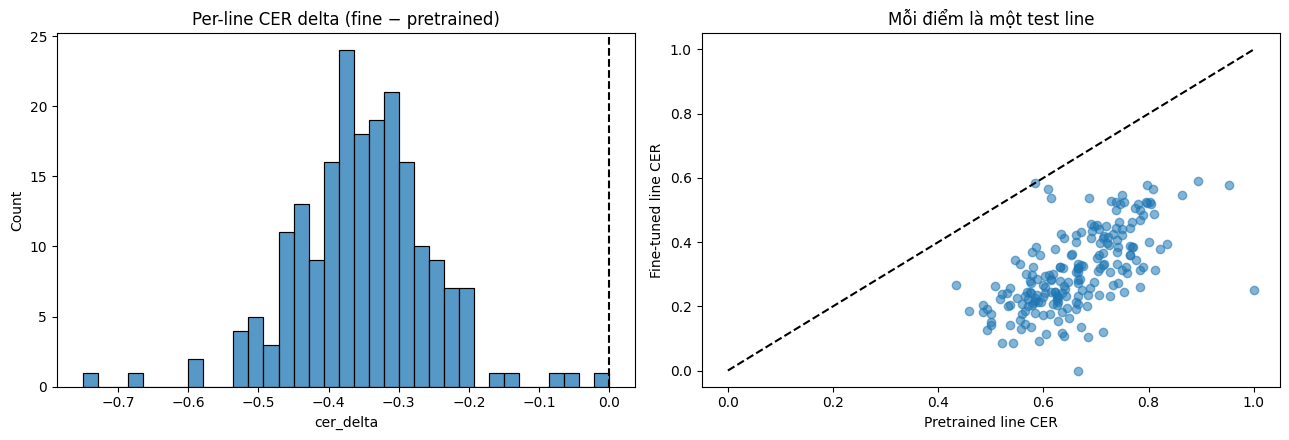

In [38]:
analysis = pd.DataFrame({
    "id": [r["id"] for r in base_pred], "truth": [r["truth"] for r in base_pred],
    "pretrained": [r["prediction"] for r in base_pred], "fine_tuned": [r["prediction"] for r in fine_pred],
})
analysis["chars"] = analysis.truth.str.len()
analysis["pretrained_line_cer"] = [edit_distance(t, p)/max(len(t),1) for t,p in zip(analysis.truth, analysis.pretrained)]
analysis["fine_tuned_line_cer"] = [edit_distance(t, p)/max(len(t),1) for t,p in zip(analysis.truth, analysis.fine_tuned)]
analysis["cer_delta"] = analysis.fine_tuned_line_cer - analysis.pretrained_line_cer
display(analysis.sort_values("cer_delta").head(10).style.set_caption("Cải thiện nhiều nhất"))
display(analysis.sort_values("cer_delta", ascending=False).head(10).style.set_caption("Tệ đi nhiều nhất"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(analysis, x="cer_delta", bins=35, ax=axes[0]); axes[0].axvline(0, color="black", ls="--")
axes[0].set_title("Per-line CER delta (fine − pretrained)")
axes[1].scatter(analysis["pretrained_line_cer"], analysis["fine_tuned_line_cer"], alpha=.55)
limit = max(1, analysis[["pretrained_line_cer","fine_tuned_line_cer"]].to_numpy().max())
axes[1].plot([0,limit],[0,limit],"k--"); axes[1].set(xlabel="Pretrained line CER", ylabel="Fine-tuned line CER", title="Mỗi điểm là một test line")
fig.tight_layout(); fig.savefig(PLOT_DIR / "paired-error-analysis.png", dpi=170, bbox_inches="tight"); plt.show()


## 11. Đóng gói model và provenance

Notebook luôn xuất:

- `easyocr-handwriting-research-finetuned.zip`: epoch sau fine-tune tốt nhất, kể cả khi chưa thắng baseline;
- `easyocr-handwriting-deployment-selected.zip`: checkpoint thắng validation CER; có thể là pretrained;
- `easyocr-experiment-report.zip`: metrics, prediction, biểu đồ và provenance.

Mỗi model package có `.pth`, `.yaml`, `.py` cùng stem để EasyOCR load bằng `recog_network="viet_handwriting"`.


In [46]:
import yaml

CUSTOM_STEM = "viet_handwriting"
MODEL_CODE = "\n".join([
    "import torch.nn as nn",
    "from easyocr.model.modules import VGG_FeatureExtractor, BidirectionalLSTM",
    "",
    "class Model(nn.Module):",
    "    def __init__(self, input_channel, output_channel, hidden_size, num_class):",
    "        super().__init__()",
    "        self.FeatureExtraction = VGG_FeatureExtractor(input_channel, output_channel)",
    "        self.AdaptiveAvgPool = nn.AdaptiveAvgPool2d((None, 1))",
    "        self.SequenceModeling = nn.Sequential(",
    "            BidirectionalLSTM(output_channel, hidden_size, hidden_size),",
    "            BidirectionalLSTM(hidden_size, hidden_size, hidden_size),",
    "        )",
    "        self.Prediction = nn.Linear(hidden_size, num_class)",
    "    def forward(self, input, text):",
    "        visual = self.FeatureExtraction(input)",
    "        visual = self.AdaptiveAvgPool(visual.permute(0, 3, 1, 2)).squeeze(3)",
    "        return self.Prediction(self.SequenceModeling(visual).contiguous())",
    "",
])

def build_model_package(folder, state, source, epoch):
    folder.mkdir(parents=True, exist_ok=True)
    state_path = folder / f"{CUSTOM_STEM}.pth"
    if isinstance(state, dict):
        fixed = state if next(iter(state)).startswith("module.") else {"module."+k:v for k,v in state.items()}
        torch.save(fixed, state_path)
    else:
        shutil.copy2(state, state_path)
    (folder / f"{CUSTOM_STEM}.py").write_text(MODEL_CODE, encoding="utf-8")
    with (folder / f"{CUSTOM_STEM}.yaml").open("w", encoding="utf-8") as stream:
        yaml.safe_dump({"imgH": CFG["image_height"], "lang_list": CFG["languages"],
                        "character_list": character,
                        "network_params": {"input_channel": 1, "output_channel": 256, "hidden_size": 256}},
                       stream, allow_unicode=True, sort_keys=False)
    (folder / "provenance.json").write_text(json.dumps({
        "source": source, "architecture": "EasyOCR Latin Gen2 / VGG-BiLSTM-CTC",
        "easyocr_version": easyocr.__version__, "base_sha256": baseline_sha256,
        "character_sha256": character_sha256, "dataset": CFG["dataset"],
        "dataset_revision": prep["revision"], "repo_commit": REPO_COMMIT,
        "seed": CFG["seed"], "checkpoint_epoch": epoch,
    }, ensure_ascii=False, indent=2), encoding="utf-8")
    return shutil.make_archive(str(folder), "zip", root_dir=folder)

fine_folder = PACKAGE_DIR / "easyocr-handwriting-research-finetuned"
deploy_folder = PACKAGE_DIR / "easyocr-handwriting-deployment-selected"
fine_zip = build_model_package(fine_folder, BEST_FT, f"fine-tuned epoch {best_ft_epoch}", best_ft_epoch)
selected_state = BEST_FT if selected_source == "fine-tuned" else baseline_state
deploy_zip = build_model_package(deploy_folder, selected_state, f"{selected_source} epoch {selected_epoch}", selected_epoch)


In [47]:
# Save report files.
for name, records in (("pretrained-test-predictions", base_pred), ("finetuned-test-predictions", fine_pred)):
    with (RUN_DIR / f"{name}.jsonl").open("w", encoding="utf-8") as f:
        for row in records: f.write(json.dumps(row, ensure_ascii=False) + "\n")
analysis.to_csv(RUN_DIR / "error-analysis.csv", index=False, encoding="utf-8-sig")

verdict = "fine-tuned improved validation CER" if selected_source == "fine-tuned" else "fine-tuned did not beat pretrained on validation CER"
report = {
    "experiment": "EasyOCR pretrained vs our EasyOCR fine-tuned on UIT-HWDB",
    "verdict": verdict, "deployment_selected": selected_source,
    "baseline_validation": baseline_val, "best_finetuned_validation_cer": best_ft_cer,
    "best_finetuned_epoch": best_ft_epoch, "pretrained_test": base_test,
    "finetuned_test": fine_test, "paired_bootstrap": bootstrap,
    "config": CFG, "repo_commit": REPO_COMMIT, "dataset_revision": prep["revision"],
    "base_sha256": baseline_sha256, "character_sha256": character_sha256,
}
(RUN_DIR / "comparison.json").write_text(json.dumps(report, ensure_ascii=False, indent=2), encoding="utf-8")
report_folder = PACKAGE_DIR / "easyocr-experiment-report"
if report_folder.exists(): shutil.rmtree(report_folder)
report_folder.mkdir(parents=True)
for filename in ("comparison.json", "history.json", "error-analysis.csv",
                 "pretrained-test-predictions.jsonl", "finetuned-test-predictions.jsonl"):
    source = RUN_DIR / filename
    if source.exists(): shutil.copy2(source, report_folder / filename)
shutil.copytree(PLOT_DIR, report_folder / "plots")
report_zip = shutil.make_archive(str(report_folder), "zip", root_dir=report_folder)
print(json.dumps({"verdict": verdict, "fine_model": fine_zip, "deployment_model": deploy_zip,
                  "report_plots": report_zip}, ensure_ascii=False, indent=2))


{
  "verdict": "fine-tuned improved validation CER",
  "fine_model": "/kaggle/working/vietdoc-ocr/runs/easyocr_latin_g2_uithwdb_seed42_lr3e-5_v1/packages/easyocr-handwriting-research-finetuned.zip",
  "deployment_model": "/kaggle/working/vietdoc-ocr/runs/easyocr_latin_g2_uithwdb_seed42_lr3e-5_v1/packages/easyocr-handwriting-deployment-selected.zip",
  "report_plots": "/kaggle/working/vietdoc-ocr/runs/easyocr_latin_g2_uithwdb_seed42_lr3e-5_v1/packages/easyocr-experiment-report.zip"
}


In [48]:
# Smoke-test package triển khai bằng API custom model chính thức của EasyOCR.
deploy_pth = deploy_folder / f"{CUSTOM_STEM}.pth"
smoke_models = RUN_DIR / "smoke-models"; smoke_networks = RUN_DIR / "smoke-networks"
smoke_models.mkdir(exist_ok=True); smoke_networks.mkdir(exist_ok=True)
shutil.copy2(deploy_pth, smoke_models / deploy_pth.name)
shutil.copy2(deploy_folder / f"{CUSTOM_STEM}.yaml", smoke_networks / f"{CUSTOM_STEM}.yaml")
shutil.copy2(deploy_folder / f"{CUSTOM_STEM}.py", smoke_networks / f"{CUSTOM_STEM}.py")
smoke_reader = easyocr.Reader(CFG["languages"], gpu="cuda", detector=False,
    recog_network=CUSTOM_STEM, model_storage_directory=str(smoke_models),
    user_network_directory=str(smoke_networks), download_enabled=False, quantize=False, verbose=False)
smoke_image = np.asarray(Image.open(DATA_DIR / rows["val"][0]["image"]).convert("L"))
smoke_output = smoke_reader.recognize(smoke_image, detail=0, paragraph=False)
assert isinstance(smoke_output, list)
print("✅ Deployment package reload OK:", smoke_output[:1])


✅ Deployment package reload OK: ['KHÁI QUAT Vẽ BIỂNt ĐẢo VIỀT NAM']


In [49]:
# Tải artifact về máy trước khi Kaggle session hết hạn.
display(FileLink(fine_zip))
display(FileLink(deploy_zip))
display(FileLink(str(RUN_DIR / "comparison.json")))
display(FileLink(str(PLOT_DIR / "training-curves.png")))
display(FileLink(str(PLOT_DIR / "pretrained-vs-finetuned.png")))


/kaggle/working/vietdoc-ocr/runs/easyocr_latin_g2_uithwdb_seed42_lr3e-5_v1/packages/easyocr-handwriting-research-finetuned.zip

/kaggle/working/vietdoc-ocr/runs/easyocr_latin_g2_uithwdb_seed42_lr3e-5_v1/packages/easyocr-handwriting-deployment-selected.zip

/kaggle/working/vietdoc-ocr/runs/easyocr_latin_g2_uithwdb_seed42_lr3e-5_v1/comparison.json

/kaggle/working/vietdoc-ocr/runs/easyocr_latin_g2_uithwdb_seed42_lr3e-5_v1/plots/training-curves.png

/kaggle/working/vietdoc-ocr/runs/easyocr_latin_g2_uithwdb_seed42_lr3e-5_v1/plots/pretrained-vs-finetuned.png

## 12. Load model vào app local

Giải nén `easyocr-handwriting-deployment-selected.zip`, rồi đặt ba file cùng stem trong hai thư mục như dưới:

```python
import easyocr

reader = easyocr.Reader(
    ['vi', 'en'],
    recog_network='viet_handwriting',
    model_storage_directory='models/easyocr',       # chứa viet_handwriting.pth
    user_network_directory='models/easyocr/user',   # chứa .yaml và .py
    gpu=False,                                      # local GTX 1650/CPU đều được
)
```

Trong sản phẩm nhiều trang, giữ detector EasyOCR/CRAFT để tìm vùng chữ, sau đó đưa từng crop dòng vào recognizer custom. Benchmark notebook này chỉ chứng minh phần recognizer; muốn tuyên bố chất lượng end-to-end cần một test set ảnh trang có ground-truth box riêng.


## 13. Cách diễn giải kết quả đúng

- Nếu CER/WER giảm, Exact Match tăng và CI của delta CER nằm dưới 0: có bằng chứng run này cải thiện recognizer trên test subset đã khai báo.
- Nếu metric trái chiều: báo đầy đủ cả ba metric, ưu tiên metric chính CER đã chốt trước.
- Nếu fine-tuned tệ hơn: đây là kết quả hợp lệ. Kiểm tra domain, lượng dữ liệu, crop/geometry, learning rate và catastrophic forgetting; không đảo nhãn biểu đồ và không đổi số.
- Không viết “EasyOCR không hỗ trợ handwriting”. Viết chính xác hơn: checkpoint Latin pretrained không được tối ưu riêng cho kiểu chữ viết tay mục tiêu, nên ta thực hiện domain adaptation.

Mẫu CV trung thực:

> Fine-tuned the EasyOCR Latin Gen2 VGG-BiLSTM-CTC recognizer on a writer-disjoint Vietnamese handwriting split; implemented reproducible CER/WER/Exact-Match evaluation, paired bootstrap confidence intervals, early stopping, regression-safe checkpoint selection, and deployable custom-model packaging.


## Tài liệu chính

- [EasyOCR official repository](https://github.com/JaidedAI/EasyOCR)
- [EasyOCR custom model guide](https://github.com/JaidedAI/EasyOCR/blob/master/custom_model.md)
- [EasyOCR trainer repository](https://github.com/JaidedAI/EasyOCR/tree/master/trainer)
- [UIT-HWDB dataset card](https://huggingface.co/datasets/blue7012/UIT_HWDB)

## Checklist trước khi đưa GitHub/CV

- [ ] Kaggle notebook chạy `Run All` từ session sạch, không sửa cell giữa chừng.
- [ ] Lưu output version và tải đủ 2 model ZIP + `comparison.json` + plots.
- [ ] README ghi chính xác dataset revision, EasyOCR version, test count và metric.
- [ ] Không commit `.pth`, dataset images, token hoặc toàn bộ thư mục `runs/`.
- [ ] Chỉ đưa con số lên CV sau khi smoke-test package reload thành công.
